In [15]:
import pandas as pd
import matplotlib.pyplot as plt 

In [16]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "training_linear_models"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [17]:
df = pd.read_csv("C:/Users/andsa/Documents/ML/concrete_data.csv")  
df.head()
df 

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [18]:
X = df[['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']]
y = df[['Strength']]

In [19]:
from sklearn.model_selection import train_test_split
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg.intercept_, lin_reg.coef_

(array([-28.823555]),
 array([[ 0.11899393,  0.1085356 ,  0.08215181, -0.13527626,  0.31056994,
          0.01786715,  0.02409978,  0.11643864]]))

In [21]:
lin_reg.predict(X_test)

array([[59.65804162],
       [52.0412113 ],
       [63.53513339],
       [51.57545676],
       [17.22001733],
       [39.86561321],
       [26.6982471 ],
       [44.73648869],
       [29.36619785],
       [38.18612542],
       [27.76438338],
       [19.81055461],
       [66.8940356 ],
       [52.28562112],
       [29.96928612],
       [44.45926401],
       [29.2284856 ],
       [26.53340084],
       [31.98162681],
       [32.03208356],
       [36.82327256],
       [31.77175527],
       [38.07286862],
       [25.12353728],
       [33.0993284 ],
       [33.85670933],
       [14.24140345],
       [40.33250901],
       [41.88282591],
       [21.33261142],
       [35.71648095],
       [30.96693001],
       [43.87446203],
       [45.52648807],
       [30.7629146 ],
       [29.59299935],
       [28.90650584],
       [38.85005738],
       [20.34631763],
       [38.45267413],
       [21.16537625],
       [15.88280149],
       [31.06077771],
       [50.70684031],
       [20.26957631],
       [57

Saving figure underfitting_learning_curves_plot


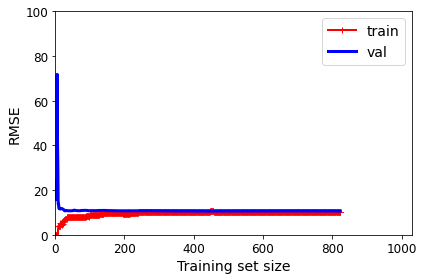

In [24]:
# learning curves

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train) + 1):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)   # not shown in the book
    plt.xlabel("Training set size", fontsize=14) # not shown
    plt.ylabel("RMSE", fontsize=14)              # not shown


lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)
plt.axis([0, 1030, 0, 100])                         # not shown in the book
save_fig("underfitting_learning_curves_plot")   # not shown
plt.show()                                      # not shown

Saving figure learning_curves_plot


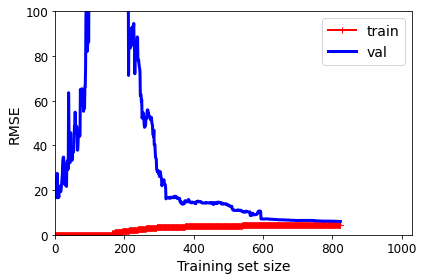

In [25]:
# poly fit 

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=3, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ])

plot_learning_curves(polynomial_regression, X, y)
plt.axis([0, 1030, 0, 100])           # not shown
save_fig("learning_curves_plot")  # not shown
plt.show()     

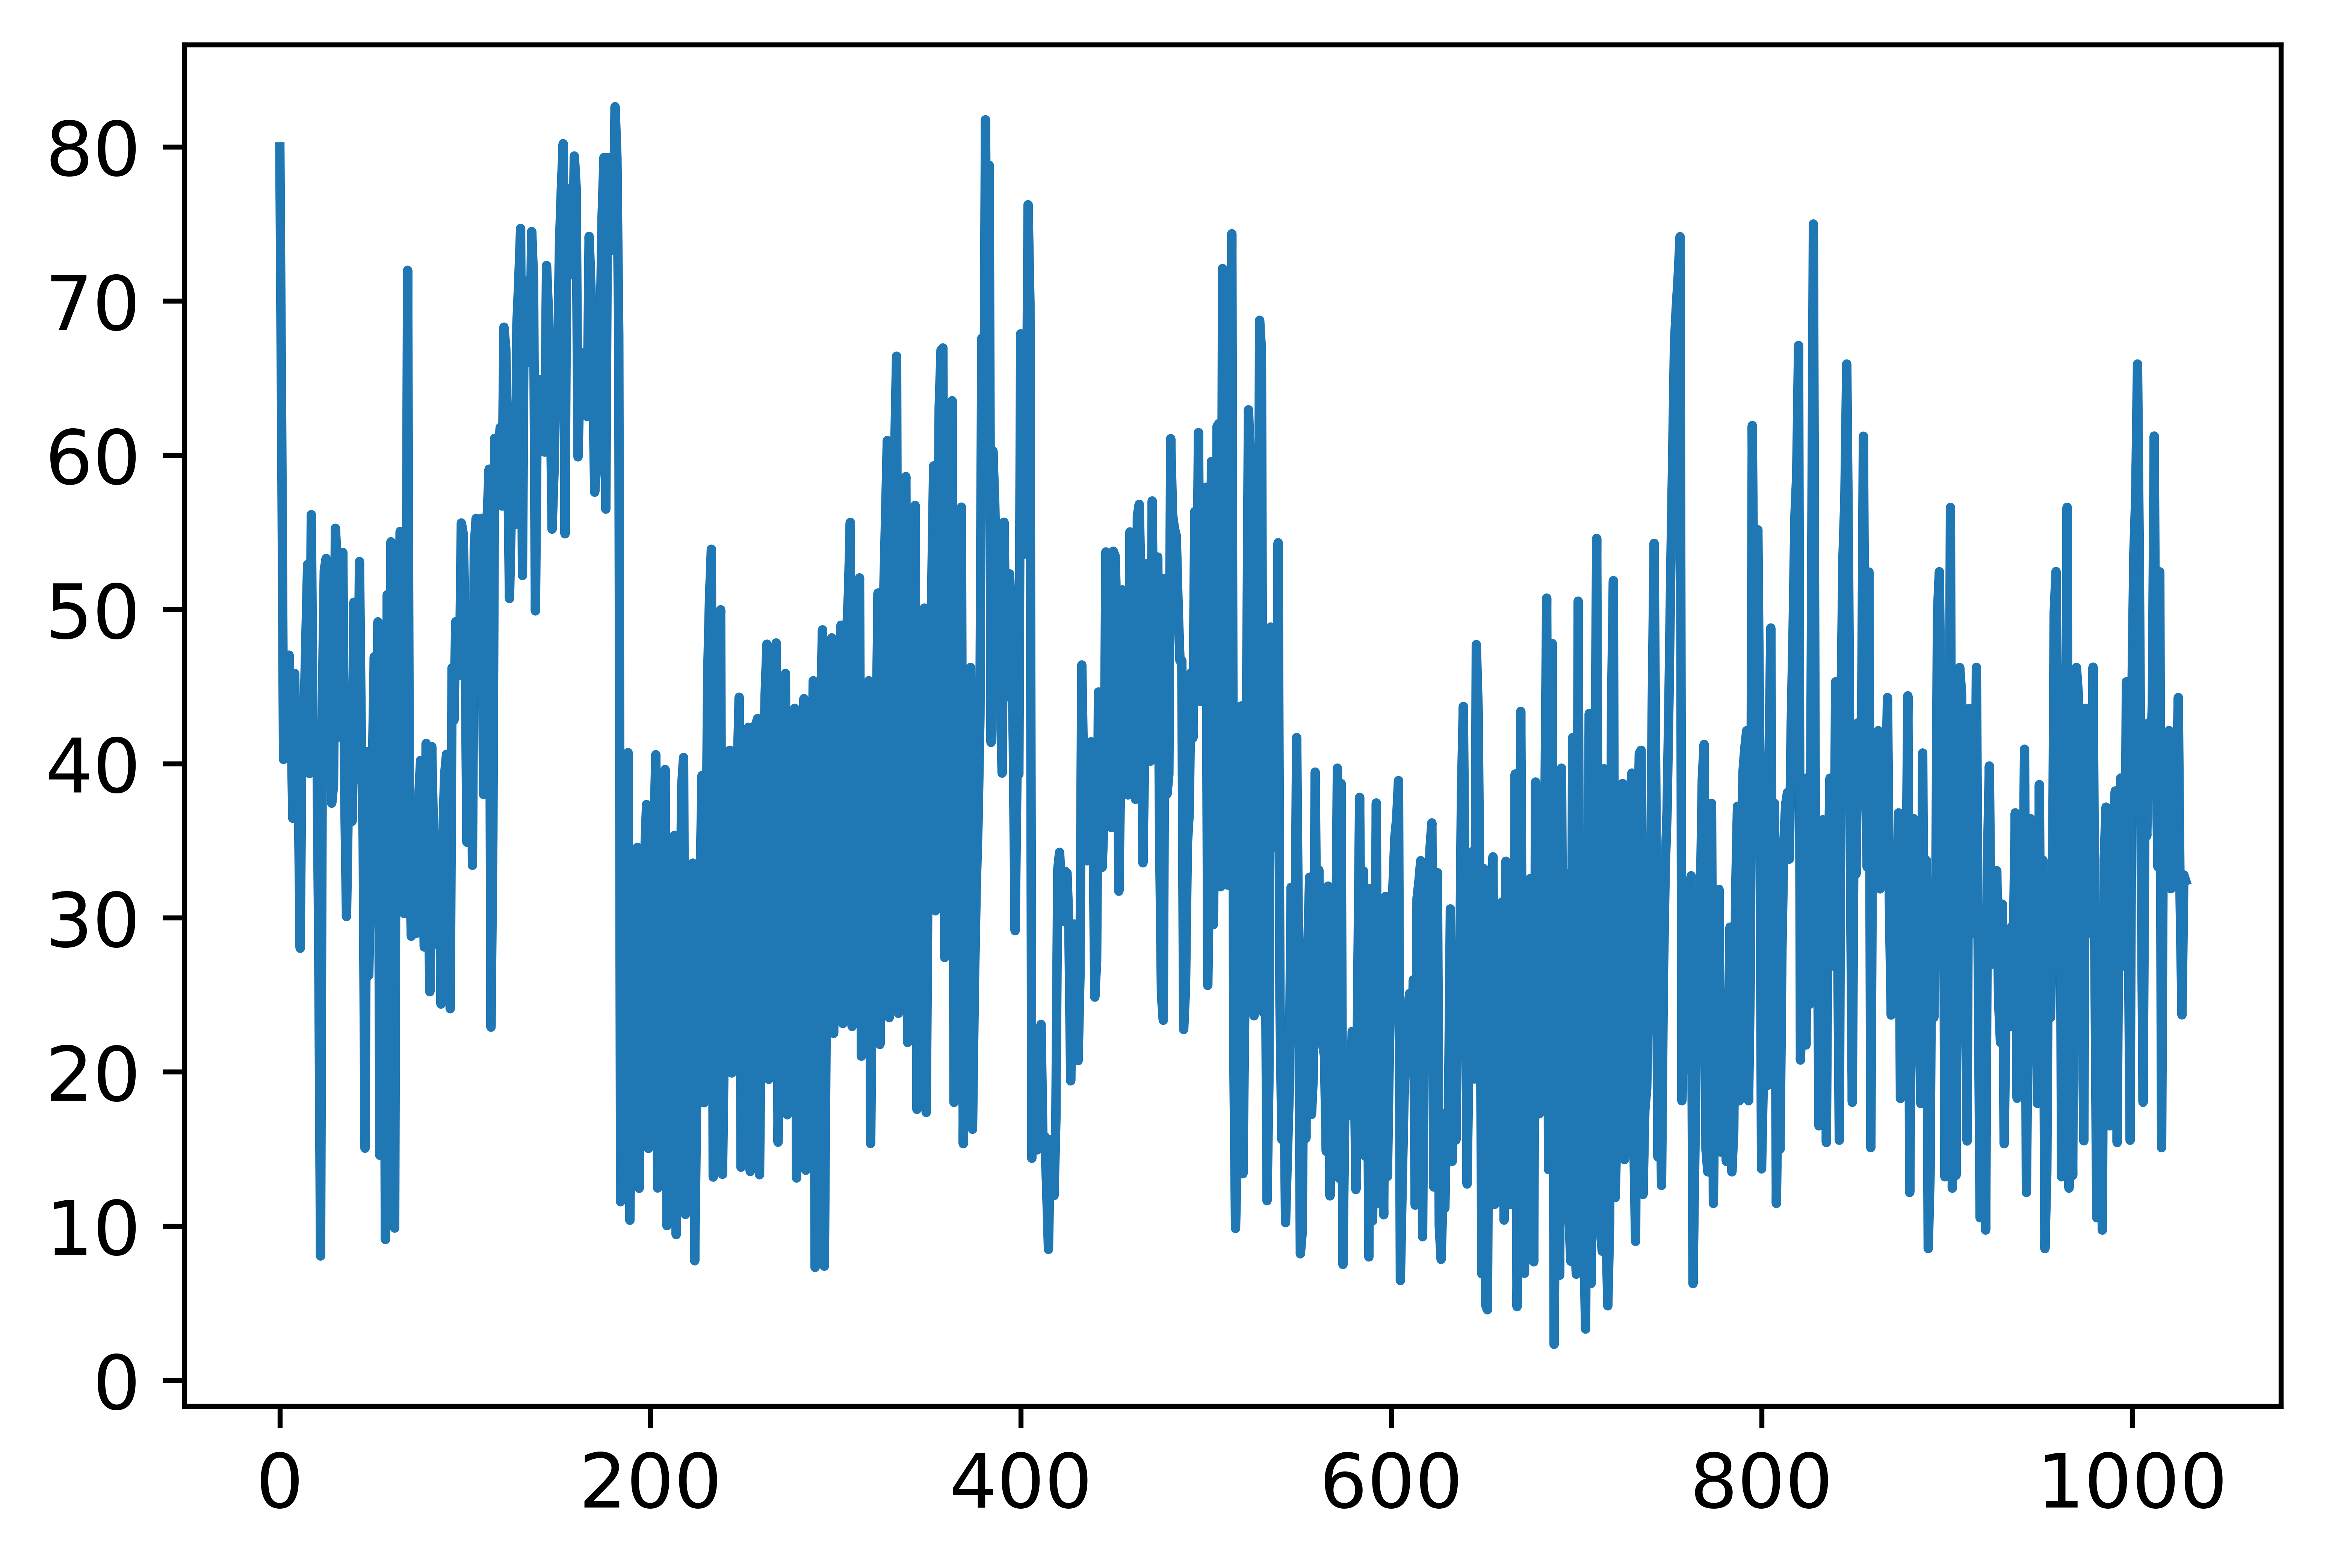

In [27]:
strength = df[['Strength']]
x = np.arange(0, len(df))

plt.rcParams['figure.dpi']=1200

plt.plot(x, strength)


